# Preprocess and annotate the H37Rv Homology Map (`k19w19`) to identify Local Repeats + Paralogous Regions

# Import statements

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
#import pickle

%matplotlib inline

In [2]:
import pandas as pd
from tqdm import tqdm
import sys

%matplotlib inline

In [3]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
import bioframe.vis

#### Set matplotlib text export settings for Adobe Illustrator

In [4]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [5]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1300)

#### Define sets of coord cols for using BioFrame

In [6]:
HmAlnPAF_CoordCols = ("Query_Name", "Query_Start", "Query_End")

PAF_Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
PAF_Target_CoordCols = ("Target_Name", "Target_Start", "Target_End")

HmReg_CoordCols = ("Chr", "Start", "End")
HHR_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols


Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")

RE_CoordCols = ("seqname", "start_0based", "end_1based")

GenomeAnno_CoordCols = ("Chrom", "Start", "End")


In [7]:
GenomeAnno_CoordCols

('Chrom', 'Start', 'End')

### Import `gcutils` custom functions

In [8]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist
from gcutils.general import parse_PAF_VarTSV, label_DF_ByOvrLapGenes
from gcutils.general import check_overlap_with_gene_group 




#from gcutils.homologymapfuncs import read_mm2_homology_map_paf
from gcutils.homologymapfuncs import read_mm2_homology_map_paf_wics
from gcutils.homologymapfuncs import label_HmMap_PAF_DF_ByOvrLapGenes, add_self_overlap_column
from gcutils.homologymapfuncs import load_and_process_mm2_homology_map_paf, Annotate_HmMap_Aln_DF
from gcutils.homologymapfuncs import build_ungapped_homology_regions

from gcutils.homologymapfuncs import get_variants_from_PAF_Aln_df

from gcutils.homologymapfuncs import label_HmMap_Variants_DF_ByOvrLapGenes

from gcutils.genomeviz_utils import plot_paralog_variants_on_ax


# Import/parse processed H37rv genome annotations

In [9]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GeneInfo_Subset_DF[['H37rv_GeneID', 'Symbol']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [10]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


## Define a table of all transposase genes within H37Rv (`Mycobrowser`)

In [11]:
Transposase_Genes_DF = H37Rv_GenomeAnno_Genes_DF[ (H37Rv_GenomeAnno_Genes_DF["Product"].str.contains("transposase")) | (H37Rv_GenomeAnno_Genes_DF["Product"].str.contains("Transposase"))  ]    
Transposase_Genes_DF.shape

(88, 12)

In [12]:
IS6110_Labled_Genes_DF = Transposase_Genes_DF[ Transposase_Genes_DF["Product"].str.contains("IS6110") ]
IS6110_Labled_Genes_DF.shape

(18, 12)

## Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [13]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [14]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [15]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Define pipeline output directories (For `Homology Map` Outputs)

In [16]:
### Define directories to PMP-SM (PacBio assembly and analysis pipeline)

### Define varaint calling pipeline output directories

Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects"

Mtb_WGA_SMK_Outputs_Dir = Project_Dir + "/Mtb-WGA-SMK-Output"

#WGA158CI_SMK_OutputDir = Mtb_WGA_SMK_Outputs_Dir + "/220427_WGA158CI_V1"
WGA151CI_SMK_OutputDir = Mtb_WGA_SMK_Outputs_Dir + "/231121_MtbSetV3_151CI"


In [17]:
#!ls -alh $WGA151CI_SMK_OutputDir | tail -n 14

# Define output directories of `mm2 homology map` results

In [18]:
target_OutputDir = WGA151CI_SMK_OutputDir

SMK_HmMap_MainDir = f"{target_OutputDir}/HomologyMapping"  

# HomMap_k19w19m200_Dir = f"{target_OutputDir}/HomologyMapping/H37Rv_Ref_HomologyMapping_k19w19m200Param"
# HomMap_k19_Dir = f"{target_OutputDir}/HomologyMapping/H37Rv_Ref_HomologyMapping_k19Param"
# HomMap_k19w19_Dir = f"{target_OutputDir}/HomologyMapping/H37Rv_Ref_HomologyMapping_k19w19Param"
# HomMap_m200_Dir = f"{target_OutputDir}/HomologyMapping/H37Rv_Ref_HomologyMapping_m200Param"

HmMap_AllParamIDs = ["k19w19",]


HmMap_FilePaths_Dict = {}

for i_ParamID in HmMap_AllParamIDs:
    print(i_ParamID)

    HmMap_FilePaths_Dict[i_ParamID] = {}

    i_HmMap_Params_OutDir = f"{SMK_HmMap_MainDir}/H37Rv_Ref_HomologyMapping_{i_ParamID}Param"

    i_HmMap_SAM = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.{i_ParamID}.VizUpdated.bam"
    i_HmMap_PAF = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.{i_ParamID}.paf"
    i_HmMap_Var_TSV = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.{i_ParamID}.TagMod.var.tsv"
    i_HmMap_Trimmed_PAF = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.{i_ParamID}.Col1to12.paf"
    i_HmMap_BED_MERGED_PATH = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.{i_ParamID}.merged.WiCounts.bed"
    
    if i_ParamID == 'k19w19':
        i_HmMap_SAM = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.VizUpdated.bam"
        i_HmMap_PAF = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.paf"
        i_HmMap_Var_TSV = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.TagMod.var.tsv"
        i_HmMap_Trimmed_PAF = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.Col1to12.paf"
        i_HmMap_BED_MERGED_PATH = f"{i_HmMap_Params_OutDir}/H37Rv.HomologyMap.merged.WiCounts.bed"

    HmMap_FilePaths_Dict[i_ParamID]["HmMap_SAM"] = i_HmMap_SAM
    HmMap_FilePaths_Dict[i_ParamID]["HmMap_PAF"] = i_HmMap_PAF
    HmMap_FilePaths_Dict[i_ParamID]["HmMap_Var_TSV"] = i_HmMap_Var_TSV
    HmMap_FilePaths_Dict[i_ParamID]["HmMap_Trimmed_PAF"] = i_HmMap_Trimmed_PAF
    HmMap_FilePaths_Dict[i_ParamID]["HmMap_BED_MERGED_PATH"] = i_HmMap_BED_MERGED_PATH


k19w19


# Parse `H37Rv-HmMap` results for `k19w19` parameter set

In [19]:

HmMap_AllParamIDs = ["k19w19"]

HmMap_ResultsDict = {}

for i_ParamID in HmMap_AllParamIDs:
    print(i_ParamID)

    HmMap_ResultsDict[i_ParamID] = {}

    # Parse pairwise alignments
    i_HmMap_Aln_DF = load_and_process_mm2_homology_map_paf(HmMap_FilePaths_Dict[i_ParamID]['HmMap_PAF'],
                                              H37Rv_GenomeAnno_Genes_DF,
                                              Transposase_Genes_DF).copy()

    # Annotate Query Region by gene groups that overlap (ESX, PE/PPE, REP13E12)

    # i_HmMap_Aln_DF["Q_Contains_Esx"]       = i_HmMap_Aln_DF["QueryOverlap_Genes"].apply(lambda x: check_overlap_with_gene_group(x, ListOf_Esx_Symbols))
    # i_HmMap_Aln_DF["Q_Contains_PEPPE"]     = i_HmMap_Aln_DF["QueryOverlap_Genes"].apply(lambda x: check_overlap_with_gene_group(x, listOf_PEPPE_Symbols))
    # i_HmMap_Aln_DF["Q_Contains_REP13E12"]  = i_HmMap_Aln_DF["QueryOverlap_Genes"].apply(lambda x: check_overlap_with_gene_group(x, listOf_13E12_Region_RvIDs))
    # i_HmMap_Aln_DF["Q_NoOverlap_Wi_PEPPE_Esx_13E12_Genes"] = ~(i_HmMap_Aln_DF["Q_Contains_Esx"] | i_HmMap_Aln_DF["Q_Contains_PEPPE"] | i_HmMap_Aln_DF["Q_Contains_REP13E12"] )

    
    # Split pairwise alignments by Local Repeat (overlapping) and Paralogous Regions (non-overlapping alignments)
    
    i_HmMap_Aln_NoOverlap_DF   = i_HmMap_Aln_DF.query("AlnOverlapsWithSelf == False")
    print( i_HmMap_Aln_NoOverlap_DF.shape )
    
    i_HmMap_Aln_LocalRepeat_DF = i_HmMap_Aln_DF.query("AlnOverlapsWithSelf == True")
    print(i_HmMap_Aln_LocalRepeat_DF.shape)


    i_ParaRegs_Merged_DF, i_HmMap_Aln_NoOverlap_V2_DF = build_ungapped_homology_regions(i_HmMap_Aln_NoOverlap_DF,
                                                                                        H37Rv_GenomeAnno_Genes_DF,
                                                                                        Transposase_Genes_DF,
                                                                                        regionPrefix = "PR_" )
    print("i_ParaRegs_Merged_DF:", i_ParaRegs_Merged_DF.shape)


    # Count overlaps with IS6110 TEs
    i_ParaRegs_Merged_DF = bf.count_overlaps(
        i_ParaRegs_Merged_DF,
        IS6110_Labled_Genes_DF,
        cols1=("Chr", "Start", "End"),
        cols2=GenomeAnno_CoordCols
    ).rename(columns={"count": "NOvrlap_IS6110_Label"})

    i_HmMap_Aln_NoOverlap_V2_DF = bf.count_overlaps(i_HmMap_Aln_NoOverlap_V2_DF,
                          IS6110_Labled_Genes_DF,
                          cols1 = PAF_Query_CoordCols,
                          cols2 = GenomeAnno_CoordCols
                          ).rename(columns={'count': 'Query_NOvrlap_IS6110_Label'})

    i_HmMap_Aln_NoOverlap_V2_DF = bf.count_overlaps(i_HmMap_Aln_NoOverlap_V2_DF,
                          IS6110_Labled_Genes_DF,
                          cols1 = PAF_Target_CoordCols,
                          cols2 = GenomeAnno_CoordCols
                          ).rename(columns={'count': 'Target_NOvrlap_IS6110_Label'})


    i_LocReps_Merged_DF, i_HmMap_Aln_LocalRepeat_V2_DF = build_ungapped_homology_regions(i_HmMap_Aln_LocalRepeat_DF,
                                                                                         H37Rv_GenomeAnno_Genes_DF,
                                                                                         Transposase_Genes_DF,
                                                                                         regionPrefix = "LR_" )
    
    print("i_LocReps_Merged_DF:", i_LocReps_Merged_DF.shape)

    i_Hm_Var_DF = parse_PAF_VarTSV(HmMap_FilePaths_Dict[i_ParamID]['HmMap_Var_TSV'])
    i_Hm_Var_SNPs_DF = i_Hm_Var_DF.query("SNP == True")

    HmMap_ResultsDict[i_ParamID]["HmMap_DF"]       = i_HmMap_Aln_DF
    HmMap_ResultsDict[i_ParamID]["HmMap_DF_NoOvrlap"]    = i_HmMap_Aln_NoOverlap_DF
    HmMap_ResultsDict[i_ParamID]["HmMap_DF_LocalRepeat"] = i_HmMap_Aln_LocalRepeat_DF
    HmMap_ResultsDict[i_ParamID]["HmMap_DF_NoOvrlap_Clustered"]    = i_HmMap_Aln_NoOverlap_V2_DF
    HmMap_ResultsDict[i_ParamID]["HmMap_DF_LocalRepeat_Clustered"] = i_HmMap_Aln_LocalRepeat_V2_DF
    HmMap_ResultsDict[i_ParamID]["ParaRegs_Merged"] = i_ParaRegs_Merged_DF
    HmMap_ResultsDict[i_ParamID]["LocReps_Merged"]  = i_LocReps_Merged_DF
    HmMap_ResultsDict[i_ParamID]["Hm_Var_DF"]       = i_Hm_Var_DF
    HmMap_ResultsDict[i_ParamID]["Hm_Var_SNPs_DF"]  = i_Hm_Var_SNPs_DF
    #HmMap_ResultsDict[i_ParamID]["_"] = _

    print(" Paralog Regions Merged Length: ", i_ParaRegs_Merged_DF["Length"].sum())
    print("\n")


k19w19
(640, 25)
(136, 25)
i_ParaRegs_Merged_DF: (200, 13)
i_LocReps_Merged_DF: (50, 13)
 Paralog Regions Merged Length:  256568




In [20]:
i_HmMap_Aln_NoOverlap_V2_DF.head()

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0


# Organize `H37Rv-HmMap-k19w19` results

### Define `Paralogous-Regions` DF

In [21]:

ParaRegs_Merged_k19w19_DF = HmMap_ResultsDict[i_ParamID]["ParaRegs_Merged"]
ParaRegs_Merged_k19w19_DF.shape

(200, 14)

In [22]:
ParaRegs_Merged_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0


### Define `LocalRepeat-Regions` DF

In [23]:
LocReps_Merged_k19w19_DF  = HmMap_ResultsDict[i_ParamID]["LocReps_Merged"]
LocReps_Merged_k19w19_DF.shape

(50, 13)

In [24]:
LocReps_Merged_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Define `HmMap Alignment` DFs

In [25]:
HmMap_Aln_k19w19_DF = HmMap_ResultsDict[i_ParamID]["HmMap_DF"] 
HmMap_Aln_k19w19_NoOverlap_DF   = HmMap_ResultsDict[i_ParamID]["HmMap_DF_NoOvrlap_Clustered"]
HmMap_Aln_k19w19_LocalRepeat_DF = HmMap_ResultsDict[i_ParamID]["HmMap_DF_LocalRepeat_Clustered"]

In [26]:
HmMap_Aln_k19w19_NoOverlap_Clustered_DF   = HmMap_ResultsDict[i_ParamID]["HmMap_DF_NoOvrlap_Clustered"]
HmMap_Aln_k19w19_LocalRepeat_Clustered_DF = HmMap_ResultsDict[i_ParamID]["HmMap_DF_LocalRepeat_Clustered"]

In [27]:
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [28]:
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 37)

In [29]:
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

In [30]:
HmMap_ResultsDict[i_ParamID]["HmMap_DF_NoOvrlap"].head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...


### Define HmMap Variant DFs

In [31]:
Hm_Var_k19w19_DF      = HmMap_ResultsDict[i_ParamID]["Hm_Var_DF"]
Hm_Var_k19w19_DF.shape

(79508, 14)

In [32]:
Hm_Var_k19w19_SNPs_DF = HmMap_ResultsDict[i_ParamID]["Hm_Var_SNPs_DF"]
Hm_Var_k19w19_SNPs_DF.shape

(65617, 14)

In [33]:
Hm_Var_k19w19_DF["Type"].value_counts()

Type
SNP    65617
INS     6966
DEL     6925
Name: count, dtype: int64

In [34]:
Hm_Var_k19w19_SNPs_DF["Type"].value_counts()

Type
SNP    65617
Name: count, dtype: int64

In [35]:
Hm_Var_k19w19_DF.head(3)

,VariantTag,Target_Name,Target_Start,Target_End,Cov,MapQ,Ref,Alt,Query_Name,Query_Start,Query_End,Strand,SNP,Type
0,V,NC_000962.3,80371,80407,11,0,GCGGCTCAACCGATATCGACAAACTCACCTTCACCT,-,NC_000962.3,3082652,3082652,+,False,DEL
1,V,NC_000962.3,80412,80413,11,0,C,T,NC_000962.3,3082657,3082658,+,True,SNP
2,V,NC_000962.3,80415,80416,11,0,A,C,NC_000962.3,3082660,3082661,+,True,SNP


In [36]:
Hm_Var_k19w19_SNPs_DF.head(3)

,VariantTag,Target_Name,Target_Start,Target_End,Cov,MapQ,Ref,Alt,Query_Name,Query_Start,Query_End,Strand,SNP,Type
1,V,NC_000962.3,80412,80413,11,0,C,T,NC_000962.3,3082657,3082658,+,True,SNP
2,V,NC_000962.3,80415,80416,11,0,A,C,NC_000962.3,3082660,3082661,+,True,SNP
3,V,NC_000962.3,80422,80423,11,0,A,G,NC_000962.3,3082667,3082668,+,True,SNP


In [37]:
Hm_Var_k19w19_DF.head(3)

,VariantTag,Target_Name,Target_Start,Target_End,Cov,MapQ,Ref,Alt,Query_Name,Query_Start,Query_End,Strand,SNP,Type
0,V,NC_000962.3,80371,80407,11,0,GCGGCTCAACCGATATCGACAAACTCACCTTCACCT,-,NC_000962.3,3082652,3082652,+,False,DEL
1,V,NC_000962.3,80412,80413,11,0,C,T,NC_000962.3,3082657,3082658,+,True,SNP
2,V,NC_000962.3,80415,80416,11,0,A,C,NC_000962.3,3082660,3082661,+,True,SNP


# Generate graph of all paralogous regions in H37Rv

Our goal is to build a graph object where nodes represent genomic regions and edges represent homology between paralogous regions.

In [38]:
%load_ext autoreload
%autoreload 2
    
from gcutils.homologymap_graph import CreatePR_DiGraph, CreatePR_UGraph
from gcutils.homologymap_graph import infer_HmMap_ParalogSet_Labels, add_PR_SetID_to_graph, subset_graph_by_PR_SetIDs, summarize_graph_stats


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [39]:
ParaRegs_Merged_k19w19_DF = HmMap_ResultsDict[i_ParamID]["ParaRegs_Merged"]
ParaRegs_Merged_k19w19_DF.shape

(200, 14)

In [40]:
HmMap_Aln_k19w19_NoOverlap_Clustered_DF   = HmMap_ResultsDict[i_ParamID]["HmMap_DF_NoOvrlap_Clustered"]
HmMap_Aln_k19w19_NoOverlap_Clustered_DF.shape

(640, 37)

### Build graph of all paralog seqs, then classify connected components as `Paralog Sets`

In [41]:
Mtb_H37Rv_PR_Sets_All_graph = CreatePR_DiGraph(ParaRegs_Merged_k19w19_DF,
                                               HmMap_Aln_k19w19_NoOverlap_Clustered_DF,
                                               edge_keep_mode='keep_all')


# Define ParalogRegion Sets (PR-Sets) based on the homology map graph
pr_set_dict, pr_set_df = infer_HmMap_ParalogSet_Labels(Mtb_H37Rv_PR_Sets_All_graph)

# Add Paralog Set IDs to nodes within the graph
Mtb_H37Rv_PR_Sets_All_graph = add_PR_SetID_to_graph(Mtb_H37Rv_PR_Sets_All_graph, pr_set_dict)

In [42]:
g_stats_dict, g_stats_df = summarize_graph_stats(Mtb_H37Rv_PR_Sets_All_graph)

In [43]:
g_stats_df.head()

,ComponentID,NumNodes
0,Comp_1,2
1,Comp_2,2
2,Comp_3,3
3,Comp_4,2
4,Comp_5,4


In [44]:
g_stats_dict.keys()

dict_keys(['num_nodes', 'num_edges', 'is_directed', 'num_connected_components', 'connected_component_sizes', 'degree_min', 'degree_max', 'degree_mean', 'degree_median', 'edge_weight_min', 'edge_weight_max', 'edge_weight_mean', 'edge_weight_median', 'num_weak_components', 'num_strong_components'])

In [45]:
g_stats_dict['num_connected_components']

70

In [46]:
g_stats_dict['num_nodes']

200

### Add PR_Set IDs (paralog set IDs) to all PR regions in the table.

In [47]:
ParaRegs_Merged_k19w19_DF["PR_SetID"] =  ParaRegs_Merged_k19w19_DF["HmRegion_Num"].map(pr_set_dict)

HmMap_Aln_k19w19_NoOverlap_Clustered_DF["PR_SetID"] =  HmMap_Aln_k19w19_NoOverlap_Clustered_DF["Query_HmRegionNum"].map(pr_set_dict) # .astype(str)


In [48]:
HmMap_Aln_k19w19_NoOverlap_Clustered_DF.shape

(640, 38)

In [49]:
ParaRegs_Merged_k19w19_DF.shape

(200, 15)

In [50]:
LocReps_Merged_k19w19_DF.shape

(50, 13)

In [51]:
HmMap_Aln_k19w19_NoOverlap_DF.head(3)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3


In [52]:
ParaRegs_Merged_k19w19_DF.head(4)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4


In [53]:
LocReps_Merged_k19w19_DF.head(4)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003


In [54]:
ParaRegs_Merged_k19w19_DF.query("PR_SetID == 'PR_Set_3' ")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
74,74,NC_000962.3,1788513,1789865,1789189.0,1352,"Rv1587c,Rv1588c",0,2,2,1,74,PR_HmRegion_074,0,PR_Set_3
180,180,NC_000962.3,3883535,3884921,3884228.0,1386,"Rv3466,Rv3467",0,2,2,1,180,PR_HmRegion_180,0,PR_Set_3


In [55]:
ParaRegs_Merged_k19w19_DF.query("PR_SetID == 'PR_Set_28' ")

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
42,42,NC_000962.3,1160538,1161167,1160852.5,629,"esxI,esxJ",0,4,4,3,42,PR_HmRegion_042,0,PR_Set_28
54,54,NC_000962.3,1340494,1341292,1340893.0,798,"PPE18,esxK,esxL",0,4,4,4,54,PR_HmRegion_054,0,PR_Set_28
87,87,NC_000962.3,2030331,2030983,2030657.0,652,"esxM,esxN",0,4,4,4,87,PR_HmRegion_087,0,PR_Set_28
113,113,NC_000962.3,2625885,2626683,2626284.0,798,"esxO,esxP,Rv2348c",0,4,4,4,113,PR_HmRegion_113,0,PR_Set_28
189,189,NC_000962.3,4059983,4060591,4060287.0,608,"esxV,esxW",0,4,4,3,189,PR_HmRegion_189,0,PR_Set_28


# Infer variants based on `cs` tag of all HomologyMap alignments (PAF)

In [56]:
HmMap_Aln_k19w19_NoOverlap_Clustered_DF.head(1)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1


In [57]:
HmMap_Aln_k19w19_NoOverlap_Clustered_DF.head(1)["cs"].values

array([':187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc:2*ca:6*ga:1*tc:1*ga:5*ag:2*ca:6*tc*ga*cg:4*cg:3*ga:1*tg*cg*ct:2*ag:10*cg:1*ca:1*gt:38-a:3*ag:5'],
      dtype=object)

In [58]:
HmMap_vars_PRandLR_DF = get_variants_from_PAF_Aln_df(HmMap_Aln_k19w19_DF)
HmMap_vars_PRandLR_DF.shape

(79641, 17)

In [59]:
HmMap_vars_PR_DF = get_variants_from_PAF_Aln_df(HmMap_Aln_k19w19_NoOverlap_Clustered_DF)
print(HmMap_vars_PR_DF.shape)

HmMap_vars_PR_DF = label_HmMap_Variants_DF_ByOvrLapGenes(HmMap_vars_PR_DF, H37Rv_GenomeAnno_Genes_DF)

print(HmMap_vars_PR_DF.shape)


(60402, 17)
(60402, 20)


In [60]:
HmMap_vars_LR_DF = get_variants_from_PAF_Aln_df(HmMap_Aln_k19w19_LocalRepeat_Clustered_DF)
print(HmMap_vars_LR_DF.shape)

HmMap_vars_LR_DF = label_HmMap_Variants_DF_ByOvrLapGenes(HmMap_vars_LR_DF, H37Rv_GenomeAnno_Genes_DF)

print(HmMap_vars_LR_DF.shape)


(19239, 17)
(19239, 20)


In [61]:
60402 + 19239

79641

In [62]:
HmMap_vars_PR_SNPs_DF = HmMap_vars_PR_DF.query("SNP == True")
HmMap_vars_PR_SNPs_DF.shape


(50203, 20)

In [63]:
# i_Hm_Var_DF.query("SNP == True")

In [64]:
HmMap_vars_PR_DF.shape

(60402, 20)

In [65]:
HmMap_vars_PR_SNPs_DF.shape

(50203, 20)

In [66]:
HmMap_vars_PR_DF.head()

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082652,3082652,+,-,GCGGCTCAACCGATATCGACAAACTCACCTTCACCT,False,INS,NC_000962.3,80371,80407,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [67]:
HmMap_vars_PR_SNPs_DF.head()

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
1,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
5,NC_000962.3,3082671,3082672,+,G,A,True,SNP,NC_000962.3,80426,80427,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


# Output processed data to `k19w19` HmMap dir

In [68]:
#Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

!mkdir $Main_Project_Dir

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"
!mkdir $H37_Rv_MM2_HomologyMapping_Dir

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Variants from the homology map alignments
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"


mkdir: cannot create directory ‘/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10’: File exists
mkdir: cannot create directory ‘/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2’: File exists


In [69]:
ParaRegs_Merged_k19w19_DF.to_csv(RvHmMap_Merged_ParaRegions_TSV, sep="\t", index = False)

LocReps_Merged_k19w19_DF.to_csv(RvHmMap_Merged_LocalRepeats_TSV, sep="\t", index = False)

### Homology map (pairwise alignments)
HmMap_Aln_k19w19_DF.to_csv(RvHmMap_Aln_All_TSV, sep="\t", index = False)
HmMap_Aln_k19w19_NoOverlap_Clustered_DF.to_csv(RvHmMap_Aln_PRs_NoOverlap_TSV, sep="\t", index = False)
HmMap_Aln_k19w19_LocalRepeat_Clustered_DF.to_csv(RvHmMap_Aln_LRs_WiOverlap_TSV, sep="\t", index = False)

HmMap_Aln_k19w19_NoOverlap_Clustered_DF.to_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV, sep="\t", index = False)
HmMap_Aln_k19w19_LocalRepeat_Clustered_DF.to_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV, sep="\t", index = False)

### Variants from the homology map alignments (From Paftools.js)

Hm_Var_k19w19_DF.to_csv(RvHmMap_Var_TSV, sep="\t", index = False)
Hm_Var_k19w19_SNPs_DF.to_csv(RvHmMap_Var_SNPs_TSV, sep="\t", index = False)


### Variants from the homology map alignments (variants per alignment cs tag)

HmMap_vars_PR_DF.to_csv(RvHmMap_Var_PerAln_TSV,
                        sep="\t",
                        index = False)


HmMap_vars_PR_SNPs_DF.to_csv(RvHmMap_Var_PerAln_SNPs_TSV,
                             sep="\t",
                             index = False)



In [70]:
!ls -lah $H37_Rv_MM2_HomologyMapping_Dir

total 36M
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 13  2025 .
drwxr-sr-x 2 mm774 hpc_farhat 4.0K Dec 13  2025 ..
-rw-r--r-- 1 mm774 hpc_farhat 603K Jun 16 13:53 RvHmMap.k19w19.Aln.All.tsv
-rw-r--r-- 1 mm774 hpc_farhat 521K Jun 16 13:53 RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv
-rw-r--r-- 1 mm774 hpc_farhat 521K Jun 16 13:53 RvHmMap.k19w19.Aln.NoOverlap.tsv
-rw-r--r-- 1 mm774 hpc_farhat 150K Jun 16 13:53 RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv
-rw-r--r-- 1 mm774 hpc_farhat 150K Jun 16 13:53 RvHmMap.k19w19.Aln.WiOverlap.tsv
-rw-r--r-- 1 mm774 hpc_farhat  11M Jun 16 13:53 RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv
-rw-r--r-- 1 mm774 hpc_farhat  13M Jun 16 13:53 RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv
-rw-r--r-- 1 mm774 hpc_farhat 4.8M Jun 16 13:53 RvHmMap.k19w19.variants.snps.tsv
-rw-r--r-- 1 mm774 hpc_farhat 5.9M Jun 16 13:53 RvHmMap.k19w19.variants.tsv
-rw-r--r-- 1 mm774 hpc_farhat 4.6K Jun 16 13:53 RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv
-rw-r--r--

In [71]:
!wc -l $H37_Rv_MM2_HomologyMapping_Dir/*

     777 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2/RvHmMap.k19w19.Aln.All.tsv
     641 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv
     641 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2/RvHmMap.k19w19.Aln.NoOverlap.tsv
     137 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv
     137 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2/RvHmMap.k19w19.Aln.WiOverlap.tsv
   50204 /n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv
   60403 /n/data1/hms/d

# Test PyCirclize to visualize `H37Rv Paralogous Regions`

In [72]:
from pycirclize import Circos


In [73]:
HmMap_Aln_k19w19_NoOverlap_DF.head()

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


In [74]:
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [75]:
HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1").shape

(255, 38)

In [76]:
HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID < 1").shape

(385, 38)

In [77]:
HmMap_Aln_k19w19_NoOverlap_Lt1SeqID_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID < 1")
HmMap_Aln_k19w19_NoOverlap_Lt1SeqID_DF.shape

(385, 38)

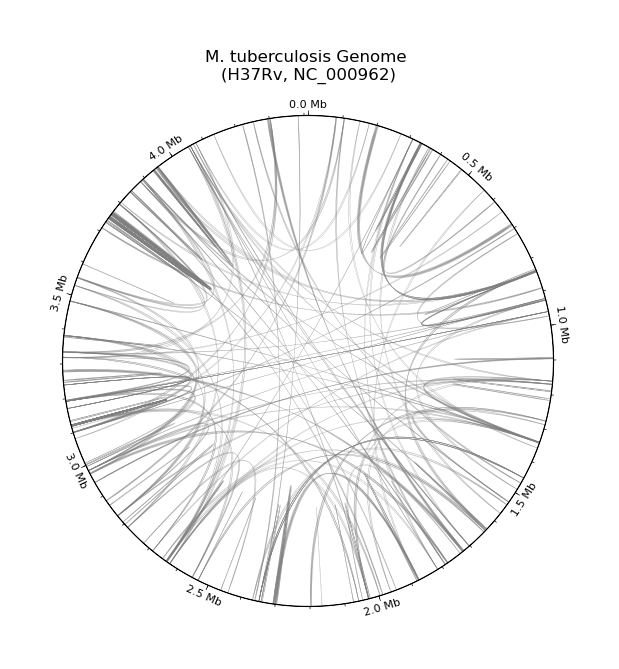

In [78]:
in_HmMapAln_DF = HmMap_Aln_k19w19_NoOverlap_Lt1SeqID_DF

circos = Circos(sectors={"NC_000962.3": 4411532})

#circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=20)
circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=120)

sector = circos.get_sector("NC_000962.3")

#### Outer track ####
# Plot outer track with xticks
major_ticks_interval = 500000
minor_ticks_interval = 100000
outer_track = sector.add_track((99.8, 100))
outer_track.axis(fc="lightgrey")
outer_track.xticks_by_interval(
    major_ticks_interval, label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb"
)
outer_track.xticks_by_interval(minor_ticks_interval, tick_length=1, show_label=False)

#####################

#### Draw links of homology map alignments ####
for i, row in in_HmMapAln_DF.iterrows():
    i_region1 = (row["Query_Name"], row["Query_Start"] - 500, row["Query_End"] + 500)
    i_region2 = (row["Target_Name"], row["Target_Start"] - 500, row["Target_End"] + 500)
    circos.link(i_region1,
                i_region2,
                color="grey", direction = 1,)
    
    #if i > 100: break

##########################################

fig = circos.plotfig(figsize = (6,6))


#### Try homology-map viz of PRs in `PR_Set_28`

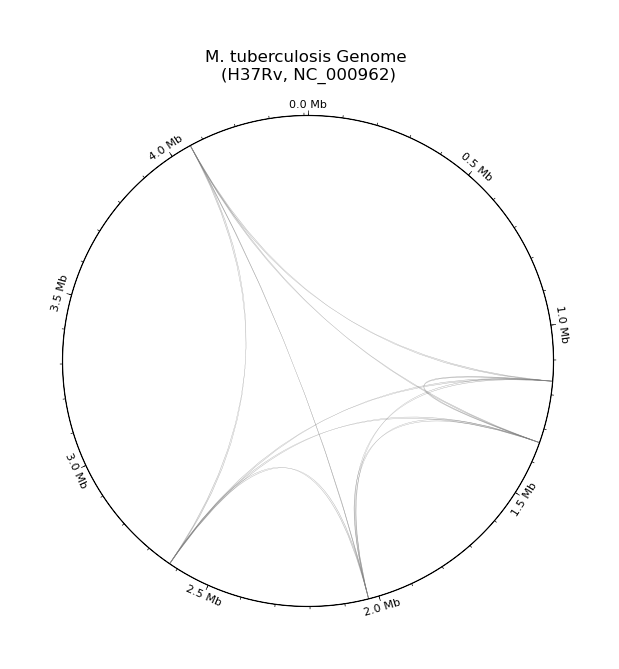

In [79]:
in_HmMapAln_DF = HmMap_Aln_k19w19_NoOverlap_Lt1SeqID_DF.query("PR_SetID == 'PR_Set_28' ")

circos = Circos(sectors={"NC_000962.3": 4411532})

#circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=20)
circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=120)

sector = circos.get_sector("NC_000962.3")

#### Outer track ####
# Plot outer track with xticks
major_ticks_interval = 500000
minor_ticks_interval = 100000
outer_track = sector.add_track((99.8, 100))
outer_track.axis(fc="lightgrey")
outer_track.xticks_by_interval(
    major_ticks_interval, label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb"
)
outer_track.xticks_by_interval(minor_ticks_interval, tick_length=1, show_label=False)

#####################

#### Draw links of homology map alignments ####
for i, row in in_HmMapAln_DF.iterrows():
    i_region1 = (row["Query_Name"], row["Query_Start"] - 500, row["Query_End"] + 500)
    i_region2 = (row["Target_Name"], row["Target_Start"] - 500, row["Target_End"] + 500)
    circos.link(i_region1,
                i_region2,
                color="grey", direction = 1,)
    
    #if i > 100: break

##########################################

fig = circos.plotfig(figsize = (6,6))


#### Try homology-map viz of PRs in `PR_Set_3`

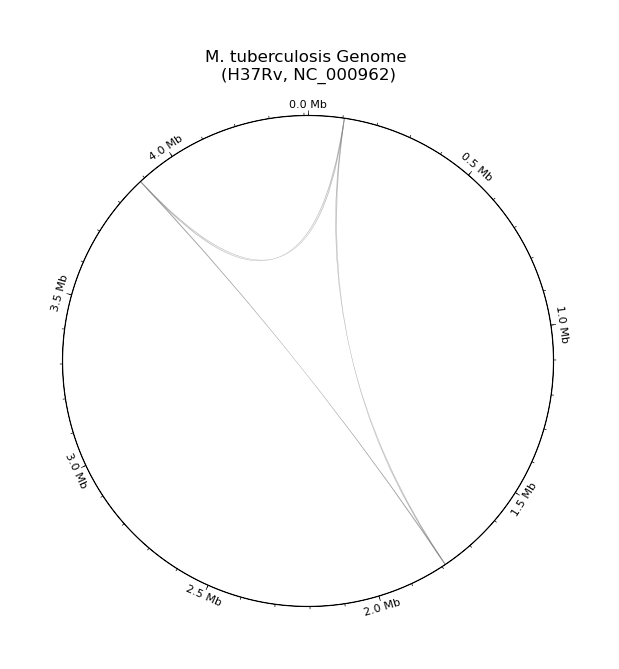

In [80]:
in_HmMapAln_DF = HmMap_Aln_k19w19_NoOverlap_Lt1SeqID_DF.query("PR_SetID == 'PR_Set_3' ")

circos = Circos(sectors={"NC_000962.3": 4411532})

#circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=20)
circos.text("M. tuberculosis Genome \n(H37Rv, NC_000962)", size=12, r=120)

sector = circos.get_sector("NC_000962.3")

#### Outer track ####
# Plot outer track with xticks
major_ticks_interval = 500000
minor_ticks_interval = 100000
outer_track = sector.add_track((99.8, 100))
outer_track.axis(fc="lightgrey")
outer_track.xticks_by_interval(
    major_ticks_interval, label_formatter=lambda v: f"{v/ 10 ** 6:.1f} Mb"
)
outer_track.xticks_by_interval(minor_ticks_interval, tick_length=1, show_label=False)

#####################

#### Draw links of homology map alignments ####
for i, row in in_HmMapAln_DF.iterrows():
    i_region1 = (row["Query_Name"], row["Query_Start"] - 500, row["Query_End"] + 500)
    i_region2 = (row["Target_Name"], row["Target_Start"] - 500, row["Target_End"] + 500)
    circos.link(i_region1,
                i_region2,
                color="grey", direction = 1,)
    
    #if i > 100: break

##########################################

fig = circos.plotfig(figsize = (6,6))


# Visualize homology map alignments for target regions
- Try viz of paralog variants for a target area

In [81]:
HmMap_vars_PR_DF.head()

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082652,3082652,+,-,GCGGCTCAACCGATATCGACAAACTCACCTTCACCT,False,INS,NC_000962.3,80371,80407,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


(60402, 20) 370
(158, 20) 3
PE_PGRS9-NC_000962.3:836147-836519 --- 1637440 1637794 354
PE_PGRS27-NC_000962.3:1633310-1634790 --- 1636705 1638392 1687
Rv2370c,PE_PGRS40-NC_000962.3:2650377-2651923 --- 1638061 1639561 1500


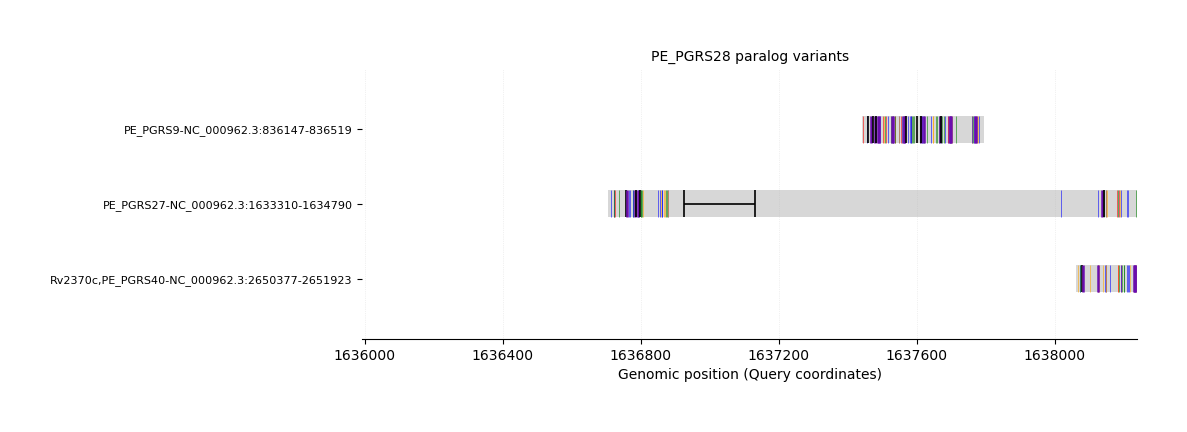

In [82]:

i_Symbol = "PE_PGRS28"

i_Gene_MutInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10


fig, ax = plt.subplots(figsize=(10, 3.5))

plot_paralog_variants_on_ax(
    ax,
    HmMap_vars_PR_DF,
    region_start = Viz_Start,
    region_end   = Viz_End,
    snp_line_width = 0.4,

    title = f"{i_Symbol} paralog variants"
)

plt.show()

(60402, 20) 370
(175, 20) 3
PPE19-NC_000962.3:1532539-1533632 --- 1339349 1340433 1084
esxO,esxP,Rv2348c-NC_000962.3:2625885-2626683 --- 1340494 1341292 798
PE31,PPE60-NC_000962.3:3894016-3895519 --- 1338923 1340433 1510


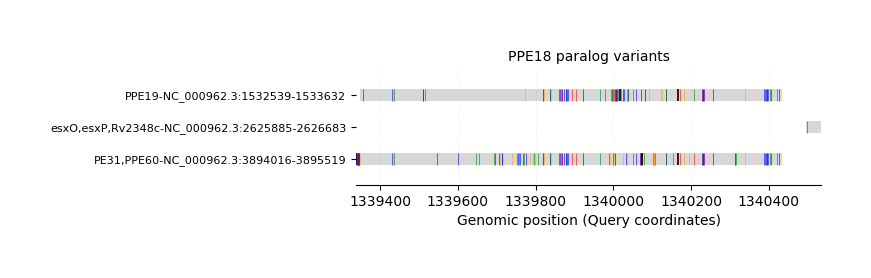

In [83]:

i_Symbol = "PPE18"

i_Gene_MutInfo_DF = H37Rv_GenomeAnno_Genes_DF.query(f"Symbol == '{i_Symbol}'")
i_Gene_Start = i_Gene_MutInfo_DF["Start"].values[0]
i_Gene_End = i_Gene_MutInfo_DF["End"].values[0]
Viz_Start, Viz_End =  i_Gene_Start - 10 , i_Gene_End + 10


fig, ax = plt.subplots(figsize=(6, 1.5))

plot_paralog_variants_on_ax(
    ax,
    HmMap_vars_PR_DF,
    region_start = Viz_Start,
    region_end   = Viz_End,
    snp_line_width = 0.4,

    title = f"{i_Symbol} paralog variants"
)

plt.show()